# Deep Reinforcement Learning - Lab Assignment 1
## Part #2 - Dynamic Programming (DP)
### Autonomous Drone Rescue using Value Iteration

**Team / Group Number (G): 178**

We model an autonomous rescue drone as a finite **Markov Decision Process (MDP)** and
solve it with **Value Iteration** to obtain the optimal value function `V*(s)` and the
optimal policy `pi*(s)`.

**Configuration derived from G = 178 (last digit 8):**
- Last digit 8 is in 5-9  -> **6x6 grid**, **3 rescue targets, 2 charging, 4 danger, 3 blocked**
- Last digit 8 is even     -> **maximum battery = 10**
- Last digit 8 is in 5-9  -> **wind probability = 30%**
- Max step limit (6x6)     -> **75 steps** (used for episode simulation)

In [1]:
# Print execution timestamp and Virtual Machine ID at the top of the notebook
import datetime
import socket
import platform

print('Execution Timestamp :', datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print('Virtual Machine ID  :', socket.gethostname())
print('Platform            :', platform.platform())
print('Python Version      :', platform.python_version())

Execution Timestamp : 2026-06-07 10:02:07
Virtual Machine ID  : Prithvis-MacBook-Air.local
Platform            : macOS-26.3-arm64-arm-64bit-Mach-O
Python Version      : 3.13.8


### Virtual Lab Execution Screenshot (timestamped proof)

Below is a screenshot of this notebook (**Part #2 - DP**) executed inside the BITS virtual lab, showing the virtual-lab clock/timestamp (top-right) and the VM ID printed by the cell above.

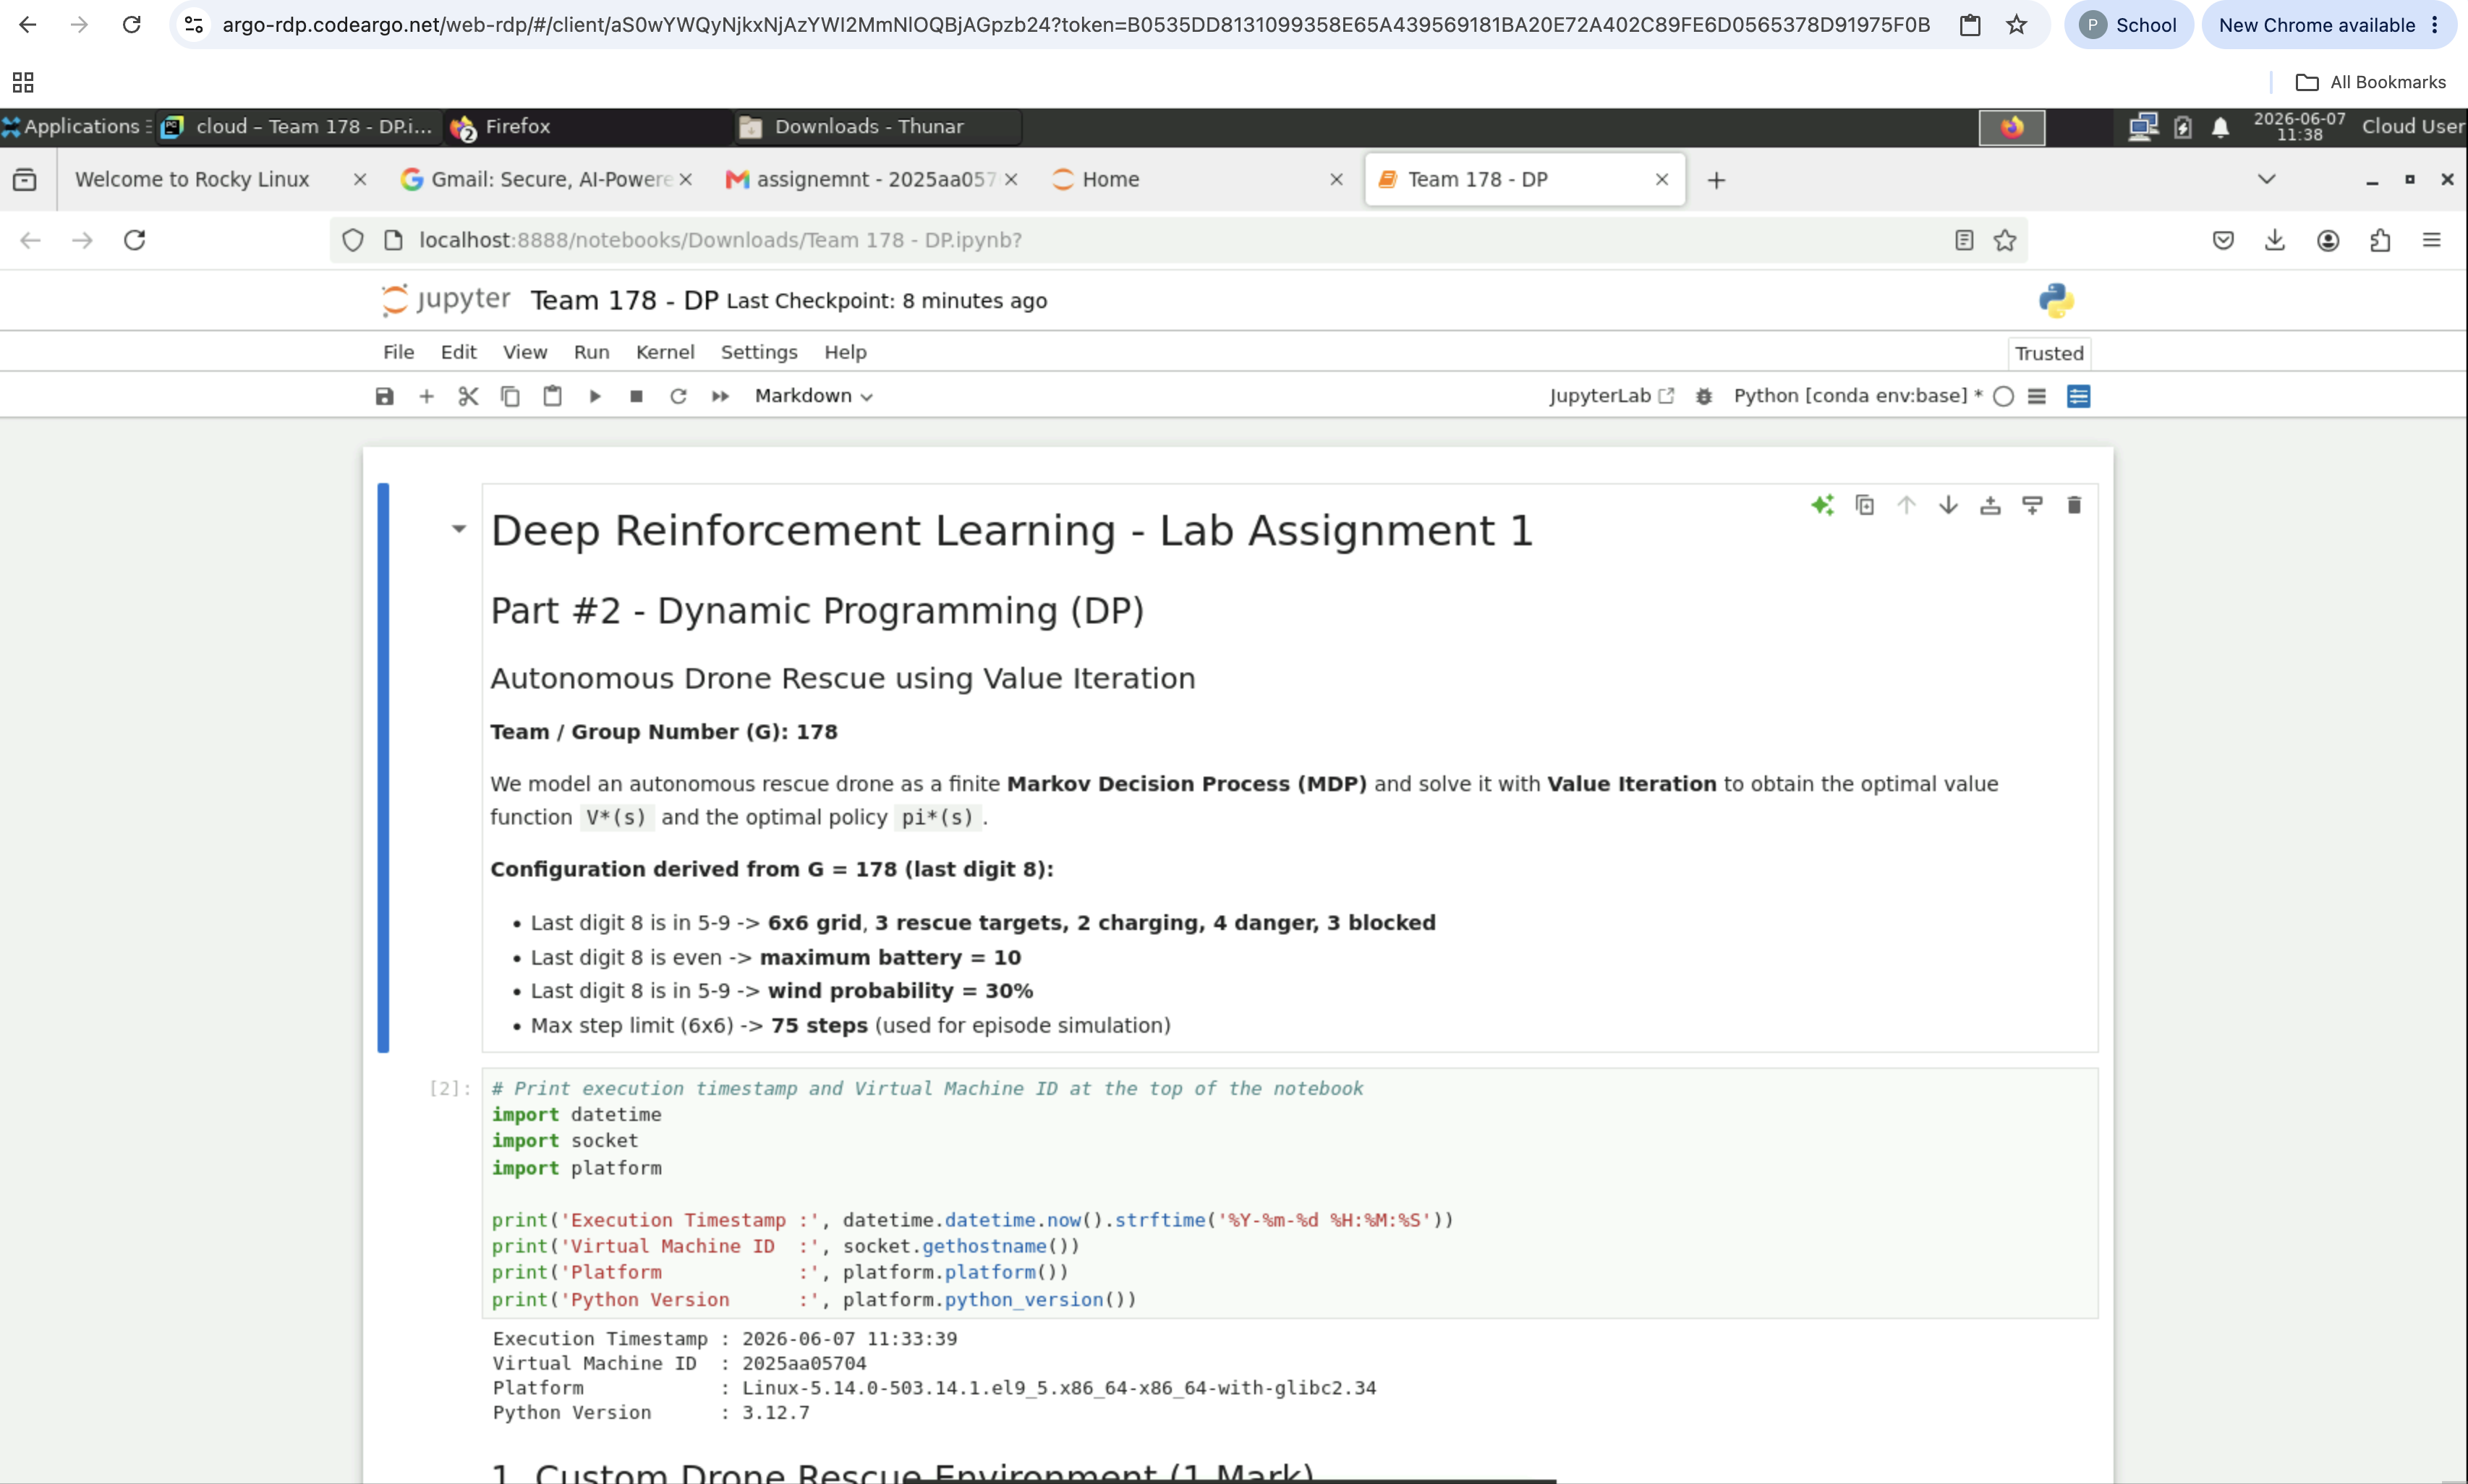

## 1. Custom Drone Rescue Environment (1 Mark)

### Grid configuration & symbol placement
Placement is generated deterministically from `G` (so it is reproducible and unique).
The **start S is fixed at the top-left corner (0,0)**. Remaining special cells are drawn
from a `G`-seeded shuffle of all other cells.

| Symbol | Meaning |
|--------|---------|
| S | Start position (0,0) |
| F | Free / safe cell |
| D | Dangerous zone |
| R | Rescue target |
| C | Charging station |
| W | Wind zone (stochastic movement) |
| X | Blocked cell / obstacle |

> The assignment specifies counts for rescue/charging/danger/blocked cells but not for
> wind zones, so we add **2 wind zones** (documented assumption) to exercise the
> stochastic-transition logic.
>
> The `+5` "reach charging station" reward is treated as a **one-time discovery bonus per
> station** (the battery still refills on every visit). Without this, repeatedly stepping
> onto a charger would form an infinite positive-reward loop and the optimal policy would
> farm the charger forever instead of rescuing - so a per-station "discovered" flag is
> added to the state (documented assumption, analogous to a rescue target paying out once).

In [2]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

G = 178                                  # group number
random.seed(G)
np.random.seed(G)

# ---- Parameters derived from the last digit of G (=8) ----
last_digit = G % 10
N = 6 if last_digit >= 5 else 5          # grid size (6x6 for digit 8)
MAX_BATTERY = 10 if last_digit % 2 == 0 else 15   # 10 (even last digit)
WIND_P = 0.30 if last_digit >= 5 else 0.20        # wind disturbance probability
MAX_STEPS = 75 if N == 6 else 50         # episode step cap (for simulation)

if last_digit >= 5:
    n_targets, n_charge, n_danger, n_block = 3, 2, 4, 3
else:
    n_targets, n_charge, n_danger, n_block = 2, 1, 3, 2
n_wind = 2                                # documented assumption

# ---- Deterministic placement of special cells (seeded by G) ----
placer = random.Random(G)                # dedicated RNG so placement is reproducible
free_cells = [(r, c) for r in range(N) for c in range(N) if (r, c) != (0, 0)]
placer.shuffle(free_cells)

rescue_targets = free_cells[0:n_targets]
charging_cells = free_cells[n_targets:n_targets + n_charge]
danger_cells   = free_cells[n_targets + n_charge:n_targets + n_charge + n_danger]
blocked_cells  = free_cells[n_targets + n_charge + n_danger:
                            n_targets + n_charge + n_danger + n_block]
wind_cells     = free_cells[n_targets + n_charge + n_danger + n_block:
                            n_targets + n_charge + n_danger + n_block + n_wind]

# Sets for O(1) membership tests
charging_set = set(charging_cells)
danger_set   = set(danger_cells)
blocked_set  = set(blocked_cells)
wind_set     = set(wind_cells)
# Map each rescue-target cell to its index in the rescued-status tuple
target_index = {cell: i for i, cell in enumerate(rescue_targets)}
# Map each charging cell to its index in the charged-status tuple (one-time +5 bonus)
charge_index = {cell: i for i, cell in enumerate(charging_cells)}

START = (0, 0)
GAMMA = 0.95                              # discount factor
THETA = 1e-3                              # value-iteration stopping threshold

print(f'Grid size        : {N} x {N}')
print(f'Max battery      : {MAX_BATTERY}')
print(f'Wind probability : {WIND_P}')
print(f'Max steps/episode: {MAX_STEPS}')
print(f'Rescue targets   : {rescue_targets}')
print(f'Charging cells   : {charging_cells}')
print(f'Danger cells     : {danger_cells}')
print(f'Blocked cells    : {blocked_cells}')
print(f'Wind cells       : {wind_cells}')

Grid size        : 6 x 6
Max battery      : 10
Wind probability : 0.3
Max steps/episode: 75
Rescue targets   : [(1, 1), (4, 4), (2, 0)]
Charging cells   : [(4, 1), (0, 1)]
Danger cells     : [(3, 5), (0, 4), (3, 3), (0, 5)]
Blocked cells    : [(3, 2), (4, 2), (1, 5)]
Wind cells       : [(2, 2), (0, 2)]


In [3]:
# ---- Action set and movement vectors ----
MOVES = ['Up', 'Down', 'Left', 'Right']           # the four movement actions
ACTIONS = MOVES + ['Hover']                        # full action space
DELTA = {'Up': (-1, 0), 'Down': (1, 0), 'Left': (0, -1), 'Right': (0, 1)}

def base_symbol(r, c):
    # Return the static map symbol for a cell (ignores the drone and rescue status).
    if (r, c) == START:        return 'S'
    if (r, c) in blocked_set:  return 'X'
    if (r, c) in charging_set: return 'C'
    if (r, c) in danger_set:   return 'D'
    if (r, c) in wind_set:     return 'W'
    if (r, c) in target_index: return 'R'
    return 'F'

def move_cell(r, c, direction):
    # Apply a movement direction. The drone stays put if the target cell is
    # off-grid or blocked (the move still consumes battery, handled by the caller).
    dr, dc = DELTA[direction]
    nr, nc = r + dr, c + dc
    if not (0 <= nr < N and 0 <= nc < N):   # off-grid -> stay
        return (r, c)
    if (nr, nc) in blocked_set:             # blocked -> stay
        return (r, c)
    return (nr, nc)

def valid_actions(state):
    # Return all valid actions from a state. Hover is always valid; a movement is
    # valid only if the adjacent cell is on the grid (moving into a blocked cell is
    # allowed but keeps the drone in place).
    r, c, b, resc, chg = state
    acts = ['Hover']
    for d in MOVES:
        dr, dc = DELTA[d]
        nr, nc = r + dr, c + dc
        if 0 <= nr < N and 0 <= nc < N:
            acts.append(d)
    return acts

# Print the symbolic grid layout
print('Initial grid layout:')
for r in range(N):
    print(' '.join(base_symbol(r, c) for c in range(N)))

Initial grid layout:
S C W F D D
F R F F F X
R F W F F F
F F X D F D
F C X F R F
F F F F F F


### State representation & transition dynamics

**State** `s = (row, col, battery, rescued, charged)` where `rescued` is a tuple of
booleans (one per rescue target) and `charged` is a tuple of booleans (one per charging
station, marking whether its one-time `+5` bonus has already been paid). This captures the
drone position, remaining battery, which targets are still pending, and which chargers are
already discovered - the information needed for the Markov property.

**Rewards** (mutually exclusive per step, matching the assignment table):
rescue target `+20`, danger zone `-10`, charging station `+5` (first visit only),
regular movement `-1`, battery exhausted `-20` (added when battery hits 0).

**Battery:** every action costs 1 unit; entering a charging station refills to full;
hovering on a charging station adds `+2` (capped at max); battery `0` ends the episode.

**Blocked / off-grid moves:** if a movement would leave the grid or enter a blocked cell
the drone stays put and the step counts as a regular move (`-1`, battery `-1`); it does
**not** re-collect the current cell's entry reward.

**Wind:** when the drone is on a wind cell and chooses a movement, with probability
`WIND_P` the realised direction is replaced by a uniform random one of the four moves
(so the intended direction keeps probability `1 - WIND_P + WIND_P/4`).

In [4]:
def transitions(state, action):
    # Return the list of (probability, next_state, reward, done) tuples for taking
    # `action` in `state`. Assumes `state` is non-terminal.
    r, c, b, resc, chg = state
    out = defaultdict(float)              # accumulate probability over identical outcomes

    def add(p, nstate, reward, done):
        out[(nstate, reward, done)] += p

    # ---------- HOVER ----------
    if action == 'Hover':
        if (r, c) in charging_set:        # hovering on a charger adds +2 battery
            nb = min(MAX_BATTERY, b + 2)
            add(1.0, (r, c, nb, resc, chg), 0.0, False)
        else:                             # hovering elsewhere costs 1 battery like a move
            nb = b - 1
            done = (nb == 0)
            reward = -1 + (-20 if done else 0)
            add(1.0, (r, c, nb, resc, chg), reward, done)
        return [(p, ns, rew, dn) for (ns, rew, dn), p in out.items()]

    # ---------- MOVEMENT (with optional wind disturbance) ----------
    if (r, c) in wind_set:                # build the (possibly randomised) direction dist.
        dist = {}
        for d in MOVES:
            p = WIND_P / 4 + ((1 - WIND_P) if d == action else 0.0)
            dist[d] = dist.get(d, 0.0) + p
    else:
        dist = {action: 1.0}

    for d, p in dist.items():
        nr, nc = move_cell(r, c, d)       # resolve movement (handles walls/blocked)
        nb = b - 1                        # movement consumes 1 battery
        resc2 = list(resc)
        chg2 = list(chg)
        cell = (nr, nc)
        # Mutually-exclusive event reward for the entered cell
        if (nr, nc) == (r, c):
            # Move blocked / off-grid: the drone stays put. Per the assignment this only
            # consumes battery as a regular move - it must NOT re-trigger the current
            # cell's entry reward (e.g. re-charging by bumping a wall while on a charger).
            reward = -1
        elif cell in charging_set:
            nb = MAX_BATTERY             # charging always refills battery to full
            ci = charge_index[cell]
            if not chg[ci]:              # +5 incentive paid only the FIRST time a station
                reward = 5               # is reached (one-time, like a rescue target);
                chg2[ci] = True          # mark this charger as already discovered
            else:
                reward = 0               # revisiting a known charger: refill only, no bonus
        elif cell in danger_set:
            reward = -10                 # danger penalty (does NOT terminate)
        elif cell in target_index and not resc[target_index[cell]]:
            reward = 20                  # rescue reward
            resc2[target_index[cell]] = True   # target now rescued (cell becomes free)
        else:
            reward = -1                  # regular movement cost
        done = False
        if nb == 0:                      # battery exhausted -> terminal with penalty
            reward += -20
            done = True
        resc2 = tuple(resc2)
        chg2 = tuple(chg2)
        if all(resc2):                   # all targets rescued -> terminal (success)
            done = True
        add(p, (nr, nc, nb, resc2, chg2), reward, done)

    return [(p, ns, rew, dn) for (ns, rew, dn), p in out.items()]

In [5]:
class DroneRescueEnv:
    # Gym-style environment exposing reset(), step(action) and render().
    def __init__(self):
        self.reset()

    def reset(self):
        # Start at the top-left corner with a full battery, no targets rescued and
        # no charging stations discovered yet.
        self.r, self.c = START
        self.b = MAX_BATTERY
        self.resc = tuple([False] * n_targets)
        self.chg = tuple([False] * n_charge)
        self.steps = 0
        return self.state()

    def state(self):
        return (self.r, self.c, self.b, self.resc, self.chg)

    def step(self, action):
        # Sample one outcome from the transition distribution of the current state.
        trans = transitions(self.state(), action)
        rnd = random.random()
        acc = 0.0
        chosen = trans[-1]
        for p, ns, rew, done in trans:
            acc += p
            if rnd <= acc:
                chosen = (p, ns, rew, done)
                break
        _, ns, reward, done = chosen
        self.r, self.c, self.b, self.resc, self.chg = ns
        self.steps += 1
        if self.steps >= MAX_STEPS:       # enforce the episode step cap
            done = True
        return ns, reward, done, {}

    def render(self):
        # Print the grid with the drone marked as 'A'; rescued targets shown as 'F'.
        print(f'Battery={self.b}  Rescued={self.resc}  Steps={self.steps}')
        for r in range(N):
            row = []
            for c in range(N):
                if (r, c) == (self.r, self.c):
                    row.append('A')                       # drone (agent)
                elif (r, c) in target_index and self.resc[target_index[(r, c)]]:
                    row.append('F')                       # already-rescued target
                else:
                    row.append(base_symbol(r, c))
            print(' '.join(row))
        print()

# Quick sanity demo of the environment dynamics
env = DroneRescueEnv()
env.reset()
print('Initial environment state:')
env.render()
for a in ['Right', 'Down', 'Hover']:
    s, rew, done, _ = env.step(a)
    print(f'Action={a:5s} -> reward={rew}, done={done}')
env.render()

Initial environment state:
Battery=10  Rescued=(False, False, False)  Steps=0
A C W F D D
F R F F F X
R F W F F F
F F X D F D
F C X F R F
F F F F F F

Action=Right -> reward=5, done=False
Action=Down  -> reward=20, done=False
Action=Hover -> reward=-1, done=False
Battery=8  Rescued=(True, False, False)  Steps=3
S C W F D D
F A F F F X
R F W F F F
F F X D F D
F C X F R F
F F F F F F



## 2. Dynamic Programming Solution - Value Iteration (2 Marks)

We enumerate all reachable states, then apply Value Iteration with discount
`gamma = 0.95` and stopping threshold `theta = 1e-3`, reporting the number of iterations,
runtime, and the final delta.

In [6]:
def enumerate_states():
    # Enumerate every non-terminal state: a non-blocked position, battery in 1..MAX,
    # any rescued-status combination that is not "all rescued" (terminal), and any
    # charging-discovered combination (which chargers have already paid their +5 bonus).
    states = []
    rescued_combos = []
    for mask in range(2 ** n_targets):    # all subsets of rescued targets
        combo = tuple(bool(mask & (1 << i)) for i in range(n_targets))
        rescued_combos.append(combo)
    charged_combos = []
    for mask in range(2 ** n_charge):     # all subsets of already-discovered chargers
        combo = tuple(bool(mask & (1 << i)) for i in range(n_charge))
        charged_combos.append(combo)
    for r in range(N):
        for c in range(N):
            if (r, c) in blocked_set:     # drone can never occupy a blocked cell
                continue
            for b in range(1, MAX_BATTERY + 1):   # battery 0 is terminal -> excluded
                for combo in rescued_combos:
                    if all(combo):        # all-rescued is terminal -> excluded
                        continue
                    for ccombo in charged_combos:
                        states.append((r, c, b, combo, ccombo))
    return states

all_states = enumerate_states()
print(f'Number of non-terminal states: {len(all_states)}')

Number of non-terminal states: 9240


In [7]:
def value_iteration(gamma=GAMMA, theta=THETA):
    # Standard Value Iteration. V for terminal states stays 0 (default dict value).
    V = defaultdict(float)
    iterations = 0
    start_time = time.time()
    final_delta = 0.0
    while True:
        delta = 0.0
        for s in all_states:
            v_old = V[s]
            best = float('-inf')
            for a in valid_actions(s):           # Bellman optimality backup
                q = 0.0
                for p, ns, reward, done in transitions(s, a):
                    q += p * (reward + (0.0 if done else gamma * V[ns]))
                best = max(best, q)
            V[s] = best
            delta = max(delta, abs(v_old - best))
        iterations += 1
        final_delta = delta
        # Per-iteration log so every Bellman sweep is visible in the PDF output
        print(f'  Iteration {iterations:3d}: delta = {delta:.6f}')
        if delta < theta:                        # converged
            break
    runtime = time.time() - start_time
    return V, iterations, runtime, final_delta

V_star, n_iter, runtime, last_delta = value_iteration()
print(f'Converged in       : {n_iter} iterations')
print(f'Runtime            : {runtime:.3f} seconds')
print(f'Final delta/error  : {last_delta:.6f} (threshold = {THETA})')

  Iteration   1: delta = 42.973747


  Iteration   2: delta = 29.956112
  Iteration   3: delta = 28.458307


  Iteration   4: delta = 18.004875


  Iteration   5: delta = 14.035551


  Iteration   6: delta = 11.353676


...

  Iteration   8: delta = 10.246692


  Iteration   9: delta = 9.734358
  Iteration  10: delta = 6.997832


  Iteration  11: delta = 3.726613


  Iteration  12: delta = 0.950000


  Iteration  13: delta = 0.431780
  Iteration  14: delta = 0.000341
Converged in       : 14 iterations
Runtime            : 0.695 seconds
Final delta/error  : 0.000341 (threshold = 0.001)


In [8]:
def greedy_policy(V, gamma=GAMMA):
    # Derive the optimal policy: the action maximising the one-step Bellman backup.
    policy = {}
    for s in all_states:
        best_a, best_q = None, float('-inf')
        for a in valid_actions(s):
            q = 0.0
            for p, ns, reward, done in transitions(s, a):
                q += p * (reward + (0.0 if done else gamma * V[ns]))
            if q > best_q:
                best_q, best_a = q, a
        policy[s] = best_a
    return policy

pi_star = greedy_policy(V_star)
# Show the optimal action from the start state: full battery, nothing rescued,
# no chargers discovered yet.
start_state = (0, 0, MAX_BATTERY, tuple([False] * n_targets), tuple([False] * n_charge))
print('Optimal action at start state', start_state, '->', pi_star[start_state])
print(f'V*(start) = {V_star[start_state]:.3f}')

Optimal action at start state (0, 0, 10, (False, False, False), (False, False)) -> Right
V*(start) = 51.117


## 3. Policy Visualisation (1 Mark)

The optimal policy is shown for **four representative state slices** so we can see how it
adapts as battery and rescue progress change:

- **Full battery, none rescued** - the drone heads toward the nearest target sequence.
- **Full battery, only last target left** - the policy now routes to the remaining target.
- **Low battery, none rescued** - the policy prioritises charging stations before targets.
- **Low battery, only last target left** - same trade-off, but biased toward the final rescue.

Arrows show movement actions; a dot indicates Hover.


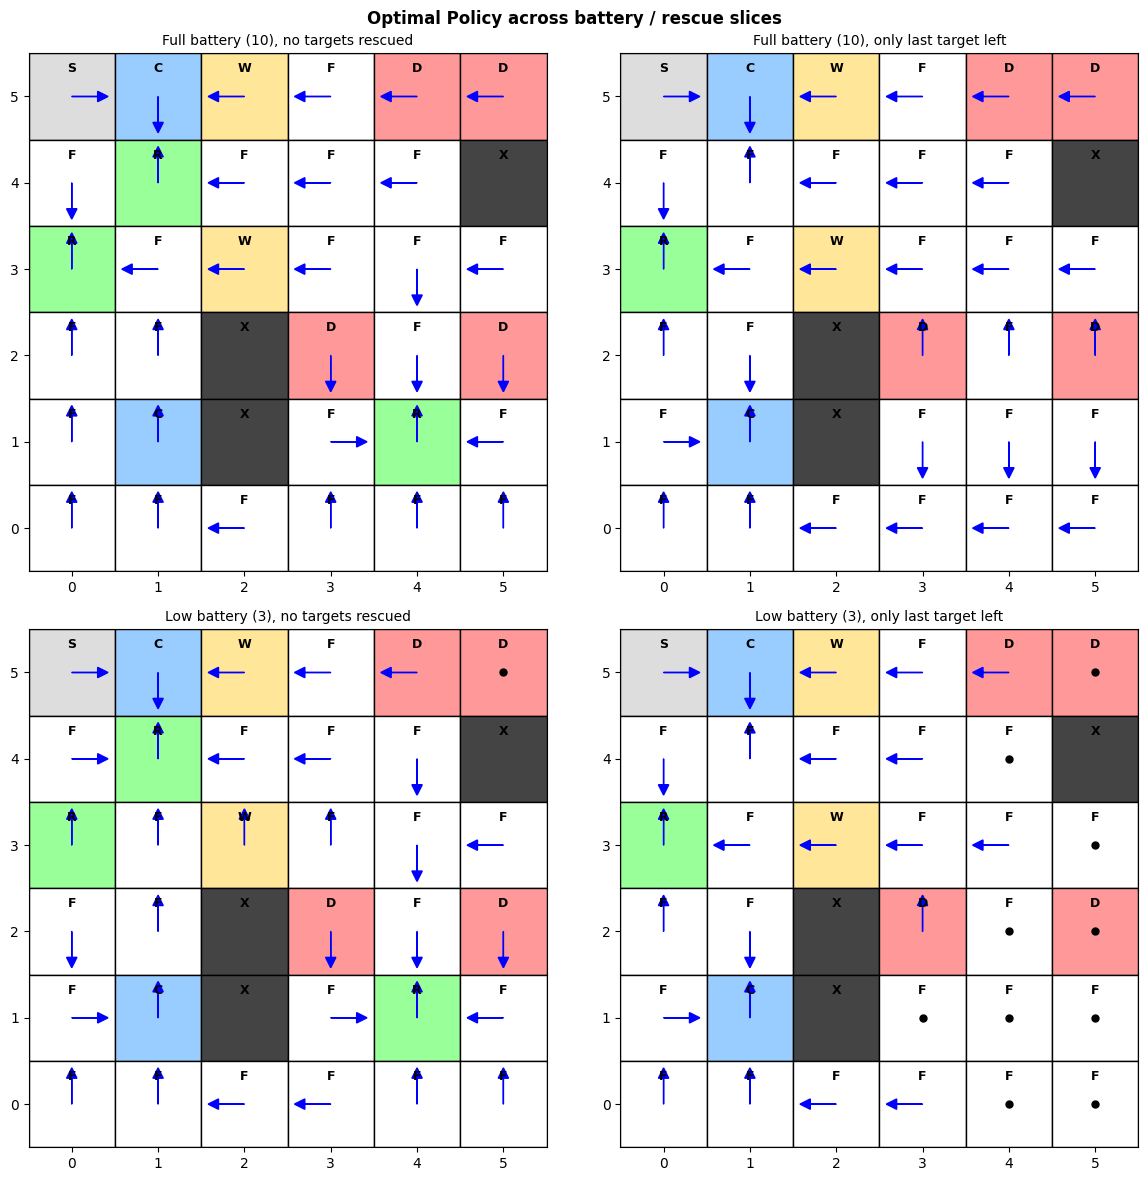

In [9]:
# Arrow vectors for plotting movement directions (note: image y-axis points down)
ARROW = {'Up': (0, 0.3), 'Down': (0, -0.3), 'Left': (-0.3, 0), 'Right': (0.3, 0)}

def draw_policy_panel(ax, batt, resc_mask, chg_mask, title):
    # Draw the optimal policy on one (battery, rescue, charge) slice.
    for r in range(N):
        for c in range(N):
            sym = base_symbol(r, c)
            # Colour-code special cells; rescued targets shown as free for clarity
            if sym == 'R' and resc_mask[target_index[(r, c)]]:
                cell_sym, color = 'F', 'white'
            else:
                cell_sym = sym
                color = {'X': '#444444', 'D': '#ff9999', 'C': '#99ccff',
                         'R': '#99ff99', 'W': '#ffe699', 'S': '#dddddd'}.get(sym, 'white')
            ax.add_patch(plt.Rectangle((c - 0.5, N - 1 - r - 0.5), 1, 1,
                                       facecolor=color, edgecolor='black'))
            ax.text(c, N - 1 - r + 0.32, cell_sym, ha='center', va='center',
                    fontsize=9, fontweight='bold')
            if sym == 'X':                      # no policy arrow on blocked cells
                continue
            s = (r, c, batt, resc_mask, chg_mask)
            a = pi_star.get(s)
            if a == 'Hover':
                ax.plot(c, N - 1 - r, 'ko', markersize=5)   # dot = hover
            elif a in ARROW:
                dx, dy = ARROW[a]
                ax.arrow(c, N - 1 - r, dx, dy, head_width=0.12,
                         head_length=0.12, fc='blue', ec='blue')
    ax.set_xlim(-0.5, N - 0.5); ax.set_ylim(-0.5, N - 0.5)
    ax.set_xticks(range(N)); ax.set_yticks(range(N))
    ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')

# Four meaningful slices to show how the policy adapts to battery + rescue progress
none_resc  = tuple([False] * n_targets)
all_but_one = tuple([True] * (n_targets - 1) + [False])  # only last target left
no_chg     = tuple([False] * n_charge)
low_batt   = max(1, MAX_BATTERY // 3)  # ~1/3 battery slice

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
draw_policy_panel(axes[0, 0], MAX_BATTERY, none_resc,  no_chg,
                  f'Full battery ({MAX_BATTERY}), no targets rescued')
draw_policy_panel(axes[0, 1], MAX_BATTERY, all_but_one, no_chg,
                  f'Full battery ({MAX_BATTERY}), only last target left')
draw_policy_panel(axes[1, 0], low_batt,     none_resc,  no_chg,
                  f'Low battery ({low_batt}), no targets rescued')
draw_policy_panel(axes[1, 1], low_batt,     all_but_one, no_chg,
                  f'Low battery ({low_batt}), only last target left')
fig.suptitle('Optimal Policy across battery / rescue slices', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Also keep the single-slice view for the heatmap cell to consume below
fixed_resc = none_resc
fixed_chg  = no_chg
fixed_batt = MAX_BATTERY


## 4. State-Value Analysis (1 Mark)

We fix the rescue status (none rescued) and battery (full) and vary only the drone
position, plotting a heatmap of `V*(s)`.

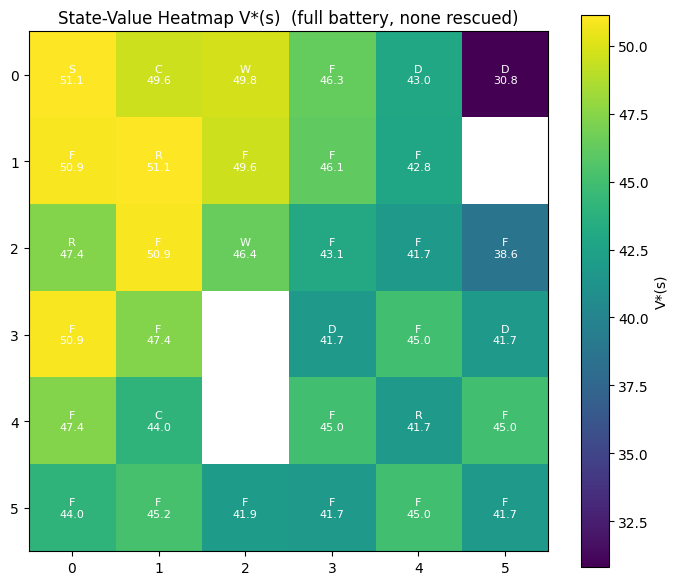

Observation: cells closer to rescue targets (R) have higher V*, while cells near
danger zones (D) and far from any target have lower V*. Charging cells (C) keep
value high by protecting against battery exhaustion, and blocked cells are absent.


In [10]:
value_grid = np.full((N, N), np.nan)        # NaN for blocked cells (shown blank)
for r in range(N):
    for c in range(N):
        if (r, c) in blocked_set:
            continue
        value_grid[r, c] = V_star[(r, c, fixed_batt, fixed_resc, fixed_chg)]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(value_grid, cmap='viridis')
plt.colorbar(im, ax=ax, label='V*(s)')
for r in range(N):                          # annotate each cell with symbol + value
    for c in range(N):
        sym = base_symbol(r, c)
        txt = f'{sym}\n{value_grid[r, c]:.1f}' if not np.isnan(value_grid[r, c]) else 'X'
        ax.text(c, r, txt, ha='center', va='center', color='white', fontsize=8)
ax.set_title('State-Value Heatmap V*(s)  (full battery, none rescued)')
ax.set_xticks(range(N))
ax.set_yticks(range(N))
plt.tight_layout()
plt.show()

print('Observation: cells closer to rescue targets (R) have higher V*, while cells near')
print('danger zones (D) and far from any target have lower V*. Charging cells (C) keep')
print('value high by protecting against battery exhaustion, and blocked cells are absent.')

## 5. DP Scalability Discussion (1 Mark)

**Curse of Dimensionality.** The state space is the product of all state variables:
`positions x battery levels x 2^(#targets) x 2^(#chargers)`. For our 6x6 grid this is
roughly `33 x 10 x 2^3 x 2^2` states. Each variable we add multiplies the size.

**How the state space grows:**
- **10x10 grid:** positions jump from ~33 to ~100, roughly **3x** more states (and the
  reachable region grows), increasing both memory and per-sweep cost.
- **More rescue targets:** the rescued-status component is `2^(#targets)`, so each extra
  target **doubles** the state space (exponential growth).
- **Dynamic weather:** adding a wind/weather variable with `w` settings multiplies the
  state space by `w` and makes transitions time-dependent, breaking the stationary
  assumption DP relies on.

**Is DP sufficient?** DP gives an exact optimal policy and is ideal here because the MDP
is small and fully known. But it requires (a) enumerating every state and (b) a known
transition model. As dimensions grow, enumeration becomes infeasible (memory + time
explode) and the model is often unknown in the real world.

**How Deep RL helps.** Methods like DQN / PPO replace the explicit value table with a
neural-network function approximator that generalises across similar states, learn
directly from sampled experience (no full model needed), and handle continuous or
high-dimensional states - exactly the regime where tabular DP fails.

**Real-world relation.** A real rescue drone faces continuous positions, noisy sensors,
unknown dynamics and changing weather; tabular DP cannot scale to this, so Deep RL (or
model-based RL with learned models) is used in practice, with DP-style value iteration
serving as the theoretical foundation and a baseline on small instances.